<center>


<div style="display: flex; justify-content: center;">
    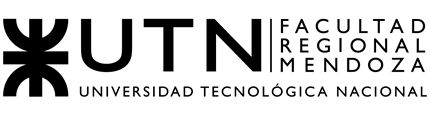
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Laboratorio 0 — Práctica integradora de Python

En los Módulos 1 al 9 aprendiste las piezas del lenguaje: variables, colecciones, estructuras de control, funciones, clases, NumPy, Matplotlib y SymPy. Este laboratorio es la primera instancia **entregable** del curso y tiene un objetivo acotado: **que pongas en juego todas esas piezas juntas** en problemas chicos y concretos de electrónica y telecomunicaciones.

A diferencia de los módulos (donde te guiamos de la mano), acá vas a recibir el enunciado y el andamiaje mínimo, y sos vos quien escribe la solución. Los ejercicios son todos **nuevos**: ninguno es el mismo que viste en los módulos, pero todos se resuelven con las mismas herramientas.

## Cómo está organizado

Hay **ocho bloques**, uno por módulo, cada uno con una actividad corta. Cada actividad indica claramente:

- Qué se pide.
- Qué herramienta de Python conviene usar.
- Cualquier concepto del dominio (electrónica, telecomunicaciones) que no hayas visto todavía.

Al final hay un **integrador** que combina varios bloques en un mini-proyecto.

## IMPORTANTE: qué celdas podés modificar

Este laboratorio es un **entregable**. Solo debés completar las celdas de actividad, que son las que aparecen con el comentario `# TU CÓDIGO AQUÍ`. Todas las demás celdas (enunciados, explicaciones, ejemplos provistos y el encabezado) **no se tocan**: la corrección se hace celda por celda de manera automática y modificar lo que no corresponde puede invalidar tu entrega.

Si necesitás probar algo fuera de una celda de actividad, hacelo en una copia aparte y revertí los cambios antes de entregar.

## Qué se espera

- Que tus celdas se ejecuten sin errores de arriba hacia abajo.
- Que los resultados sean razonables (no solo que "corra", sino que dé lo que se pide).
- Que los gráficos tengan título, etiquetas en los ejes y grilla.
- Si te trabás en un bloque, **no abandones**: seguí con los siguientes y volvé después. Los bloques son en buena medida independientes.

## Preparación: imports

Ejecutá esta celda **una sola vez** al empezar. Trae las librerías que vas a usar en todo el notebook.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 1. Tipos y operaciones numéricas

**Qué practicás del Módulo 2:** variables, operaciones aritméticas, `print` con f-strings.

### Contexto: longitud de onda

Una onda electromagnética que viaja en el vacío satisface

$$\lambda = \frac{c}{f}$$

donde:

- $\lambda$ es la **longitud de onda** en metros,
- $f$ es la **frecuencia** en hertz,
- $c \approx 3 \times 10^{8}$ m/s es la velocidad de la luz.

Por ejemplo, una señal de radio FM a 100 MHz tiene una longitud de onda de $3 \times 10^8 / 10^8 = 3$ m, que es aproximadamente la longitud de una antena dipolo FM.

### Actividad 1: longitud de onda de tres señales

Calculá la longitud de onda $\lambda$, en metros, de estas tres señales de radio:

| Señal | Frecuencia |
|-------|------------|
| AM (onda media) | 900 kHz |
| FM (banda comercial) | 100 MHz |
| Wi-Fi (banda 2.4) | 2.4 GHz |

**Herramientas sugeridas:**

- Guardá `c = 3e8` (notación científica para $3 \times 10^8$).
- Para cada frecuencia, calculá `lambda_X = c / f_X` (no uses el nombre `lambda` a secas: en Python está reservado).
- Imprimí los tres resultados con `print` y f-strings, con dos decimales: `f"{valor:.2f}"`.

In [ ]:
# TU CÓDIGO AQUÍ

## 2. Colecciones

**Qué practicás del Módulo 3:** diccionarios, listas, recorrido con `for` o comprensión.

### Contexto: notas musicales

Cada nota musical corresponde a una frecuencia fundamental bien definida. En la **octava 4** del piano, las frecuencias (en Hz) son aproximadamente:

| Nota | Frecuencia (Hz) |
|------|-----------------|
| Do  | 261.63 |
| Re  | 293.66 |
| Mi  | 329.63 |
| Fa  | 349.23 |
| Sol | 392.00 |
| La  | 440.00 |
| Si  | 493.88 |

Un diccionario es la estructura natural para representar esta tabla: la nota es la **clave**, la frecuencia es el **valor**.

### Actividad 2: frecuencias de una melodía

1. Creá un diccionario `notas` con los pares nota→frecuencia de la tabla de arriba.
2. Dada la melodía `melodia = ["Do", "Mi", "Sol", "Do", "Si", "La", "Sol"]` (las primeras notas de un arpegio), obtené la **lista de frecuencias** correspondientes.
3. Imprimí la lista resultante.

**Herramientas sugeridas:**

- Para armar el diccionario: `notas = {"Do": 261.63, "Re": 293.66, ...}`.
- Para obtener las frecuencias, hay dos caminos equivalentes, elegí el que prefieras:
  - **Bucle `for`** que recorre `melodia`, busca `notas[n]` y lo va agregando a una lista con `.append(...)`.
  - **Comprensión de lista**: `frecuencias = [notas[n] for n in melodia]`.

In [ ]:
melodia = ["Do", "Mi", "Sol", "Do", "Si", "La", "Sol"]

# TU CÓDIGO AQUÍ

## 3. Estructuras de control

**Qué practicás del Módulo 4:** `for`, `if/elif/else`, comprensiones con filtro.

### Contexto: bandas de radiofrecuencia

El espectro de radio se divide en bandas con nombres convencionales. Estas son las tres más usadas en telecomunicaciones:

| Banda | Rango de frecuencias | Ejemplo típico |
|-------|----------------------|----------------|
| HF (*High Frequency*) | 3 MHz a 30 MHz | Radio de onda corta, comunicaciones de largo alcance |
| VHF (*Very High Frequency*) | 30 MHz a 300 MHz | FM comercial, VHF marítimo |
| UHF (*Ultra High Frequency*) | 300 MHz a 3 GHz | TV digital, telefonía celular, Wi-Fi |

Dada una frecuencia en Hz, podemos clasificarla en una de estas tres bandas con condicionales.

### Actividad 3: clasificar frecuencias por banda

Te damos una lista de frecuencias medidas en un analizador de espectro (todas en Hz):

```python
frecuencias = [5e6, 27e6, 88e6, 145e6, 433e6, 915e6, 2.4e9]
```

1. Recorré la lista con un `for` y clasificá cada frecuencia en HF, VHF o UHF según la tabla de arriba. Usá `if/elif/else` con las comparaciones encadenadas (`3e6 <= f < 30e6`, etc.).
2. Imprimí una línea por frecuencia con el formato `"145000000.0 Hz → VHF"` (usá f-strings).
3. Al final, usá una **comprensión de lista** para quedarte solo con las frecuencias que caen en **VHF**, y imprimí esa sublista.

**Herramientas sugeridas:**

- `for f in frecuencias:` para recorrer.
- Dentro del bucle, armá una variable `banda` con `"HF"`, `"VHF"` o `"UHF"` según corresponda.
- La comprensión final es del estilo `vhf = [f for f in frecuencias if 30e6 <= f < 300e6]`.

In [ ]:
frecuencias = [5e6, 27e6, 88e6, 145e6, 433e6, 915e6, 2.4e9]

# TU CÓDIGO AQUÍ

## 4. Funciones

**Qué practicás del Módulo 5:** definir funciones, parámetros, retorno, composición.

### Contexto 1: frecuencia de corte de un filtro RC

Un filtro pasa-bajos RC (una resistencia $R$ en serie con un capacitor $C$ a tierra, salida sobre el capacitor) deja pasar las frecuencias bajas y atenúa las altas. La **frecuencia de corte** (donde la señal cae 3 dB) es:

$$f_c = \frac{1}{2\pi R C}$$

con $R$ en ohms y $C$ en faradios, $f_c$ queda en hertz.

### Contexto 2: ganancia en decibeles

La ganancia en **decibeles (dB)** de un amplificador a partir de una relación de tensiones se define como:

$$G_{\text{dB}} = 20 \cdot \log_{10}\!\left(\frac{V_{\text{out}}}{V_{\text{in}}}\right)$$

El dB comprime rangos muy grandes: una ganancia de 1000 equivale a 60 dB, y una de 2 equivale a aproximadamente 6 dB.

### Actividad 4: tres funciones encadenadas

1. Definí una función `fc_rc(R, C)` que devuelva la frecuencia de corte del filtro RC.
2. Definí una función `ganancia_db(v_in, v_out)` que devuelva la ganancia en dB.
3. **Composición**: calculá la ganancia total (en dB) de dos etapas de amplificación **en cascada** usando una función `ganancia_total_db(g1_db, g2_db)` que simplemente **sume** las dos ganancias (la propiedad clave del dB: al multiplicarse las ganancias lineales, las de dB se suman).

Después, probá:

- `fc_rc(R=10e3, C=100e-9)` → debería dar aproximadamente 159 Hz.
- `ganancia_db(1, 10)` → debería dar 20 dB.
- `ganancia_total_db(20, 6)` → debería dar 26 dB.

Imprimí los tres resultados con f-strings y dos decimales.

**Herramientas sugeridas:**

- Para $\log_{10}$, usá `np.log10(x)` (que opera tanto sobre escalares como sobre arrays).
- Para $\pi$ usá `np.pi`.
- Las funciones son de una sola línea cada una; no hace falta más.

In [ ]:
# TU CÓDIGO AQUÍ

## 5. Clases y objetos

**Qué practicás del Módulo 6:** definir una clase, `__init__`, atributos, métodos.

### Contexto: baterías

Una batería se caracteriza por dos valores principales:

- La **tensión nominal** en volts (por ejemplo, 12 V para una batería de auto, 3.7 V para una de celular).
- La **capacidad** en amperes-hora (Ah), que indica cuánta carga puede entregar.

A partir de estos dos datos salen dos magnitudes útiles:

- La **energía almacenada** en watts-hora: $E = V \cdot C_{\text{Ah}}$.
- La **autonomía**, en horas, cuando entrega una corriente constante $I$: $t = C_{\text{Ah}} / I$.

### Actividad 5: clase `Bateria`

Definí una clase `Bateria` con:

1. Un `__init__(self, capacidad_ah, tension)` que guarde ambos valores como atributos.
2. Un método `energia_wh(self)` que devuelva la energía almacenada en Wh.
3. Un método `autonomia(self, corriente_a)` que devuelva la autonomía en horas para una corriente dada.

Después, creá **dos** baterías y compará:

- `b1 = Bateria(capacidad_ah=60, tension=12)` — batería de auto.
- `b2 = Bateria(capacidad_ah=4, tension=3.7)` — batería de celular.

Para cada una, imprimí su energía almacenada y su autonomía entregando 0.5 A.

**Herramientas sugeridas:**

- Recordá que los métodos reciben `self` como primer parámetro y acceden a los atributos como `self.capacidad_ah` y `self.tension`.
- No hace falta herencia ni métodos especiales como `__str__`; solo lo pedido.

In [ ]:
# TU CÓDIGO AQUÍ

## 6. NumPy: generación de señales

**Qué practicás del Módulo 7:** `linspace`, operaciones vectorizadas, `np.sin`, `np.sqrt`, `np.mean`.

### Contexto: qué es un tono DTMF

**DTMF** (*Dual-Tone Multi-Frequency*) es el sistema que usan los teléfonos de tonos desde los años 60. Cuando apretás una tecla del teclado telefónico, el teléfono no genera **un** tono, sino la **suma de dos** tonos senoidales: uno de un grupo de frecuencias "bajas" (que identifica la fila de la tecla) y uno de un grupo de frecuencias "altas" (que identifica la columna).

Esta es la tabla estándar:

|          | **1209 Hz** | **1336 Hz** | **1477 Hz** |
|----------|-------------|-------------|-------------|
| **697 Hz** | 1 | 2 | 3 |
| **770 Hz** | 4 | 5 | 6 |
| **852 Hz** | 7 | 8 | 9 |
| **941 Hz** | * | 0 | # |

Por ejemplo, la tecla **"5"** genera la señal

$$x(t) = \sin(2\pi \cdot 770 \cdot t) + \sin(2\pi \cdot 1336 \cdot t).$$

El oído humano percibe los dos tonos mezclados como el sonido característico del marcado. En el otro extremo de la línea, un circuito (o un programa) detecta las dos frecuencias y deduce qué tecla se apretó.

### Contexto: frecuencia de muestreo

Una computadora no guarda una señal continua en sentido matemático: sólo puede almacenar una secuencia de **valores tomados a intervalos regulares**. La cantidad de valores que registramos por segundo se llama **frecuencia de muestreo**, se suele nombrar `fs` (del inglés *sampling frequency*) y se mide en Hz.

Por ejemplo, `fs = 8000` Hz significa que tomamos 8000 muestras por segundo, una cada $1/8000 = 125\ \mu\text{s}$. Ese valor es el estándar histórico de la telefonía digital: alcanza para representar con fidelidad la voz humana y los tonos DTMF.

Para armar el eje de tiempos `t` de una señal de duración `duracion` muestreada a `fs`:

```python
t = np.linspace(0, duracion, int(duracion * fs))
```

`duracion * fs` es la cantidad total de muestras; la envolvemos en `int(...)` porque `linspace` exige un entero.

Este concepto lo vamos a retomar con más profundidad en un laboratorio más adelante; por ahora alcanza con esta idea operativa.

### Contexto: valor RMS

El **valor RMS** (*root mean square*, valor cuadrático medio) de una señal $x$ es

$$x_{\text{RMS}} = \sqrt{\langle x^2 \rangle}$$

es decir, la raíz del promedio del cuadrado. En NumPy, con un array `x`, se calcula como:

```python
x_rms = np.sqrt(np.mean(x ** 2))
```

### Actividad 6: generar la tecla "5" y calcular su RMS

1. Definí la frecuencia de muestreo `fs = 8000` Hz (estándar en telefonía) y la duración `duracion = 0.05` (50 ms).
2. Armá el eje de tiempos `t` con `np.linspace(0, duracion, int(duracion * fs))`. La conversión a `int` es necesaria porque `linspace` requiere una cantidad entera de puntos.
3. Generá la señal de la tecla "5" como la suma de dos senoidales:
   - Una de 770 Hz.
   - Una de 1336 Hz.

   Usá operaciones vectorizadas: `np.sin(2 * np.pi * 770 * t)` opera sobre todo el array de una vez.

4. Calculá el valor RMS con la fórmula `np.sqrt(np.mean(x ** 2))`.
5. Imprimí el RMS con dos decimales.

> **Dato útil:** el RMS de una única senoidal de amplitud $A$ vale $A/\sqrt{2} \approx 0.707 \cdot A$. Acá tenés **dos** senoidales sumadas, así que el RMS va a ser distinto de $1/\sqrt{2}$. Pensalo como verificación: si te da un número razonable (entre 0.5 y 1.5), está bien.

In [ ]:
# TU CÓDIGO AQUÍ

## 7. Matplotlib: varios paneles

**Qué practicás del Módulo 8:** `subplots`, `plot`, `stem`, títulos, etiquetas.

En este bloque vas a graficar **tres señales distintas** en una misma figura con tres paneles apilados.

### Actividad 7: tres señales en subplots

Generá `t = np.linspace(0, 0.02, 500)` (20 ms, 500 puntos) y producí las siguientes tres señales:

1. **Exponencial creciente**: $x_1(t) = e^{50\,t}$. Graficala con `plot`.
2. **Tren de pulsos digitales**: un array `pulsos = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 1])` (10 bits). Esta señal es inherentemente discreta (no hay nada entre un bit y el siguiente), así que va con `stem`. En el eje horizontal usá `n = np.arange(10)`.
3. **Senoidal amortiguada**: $x_3(t) = e^{-100\,t} \cdot \cos(2\pi \cdot 200 \cdot t)$. Graficala con `plot`. Esta es la forma típica de la respuesta natural de un circuito RLC a un golpe.

Acomodá las tres en una figura de `(9, 7)` pulgadas, con tres filas y una columna, usando `fig, axs = plt.subplots(3, 1, figsize=(9, 7))`. Cada panel tiene que llevar:

- Título descriptivo.
- Etiqueta en el eje Y.
- Grilla.
- Solo el panel de **abajo** lleva etiqueta en el eje X (los otros comparten implícitamente el eje temporal).

Cerrá con `plt.tight_layout()` y `plt.show()`.

**Herramientas sugeridas:**

- `np.exp(...)` es la exponencial.
- Sobre un eje concreto `axs[i]`, se usa `axs[i].plot(...)`, `axs[i].set_title(...)`, `axs[i].set_ylabel(...)`, `axs[i].grid(True)`.
- Para `stem` la llamada es `axs[1].stem(n, pulsos)`.

In [ ]:
# TU CÓDIGO AQUÍ

## 8. SymPy: despejar simbólicamente

**Qué practicás del Módulo 9:** símbolos, `sp.solve`, sustitución con `.subs`, evaluación numérica con `.evalf`.

### Contexto

Retomemos la fórmula del filtro RC del bloque 4:

$$f_c = \frac{1}{2\pi R C}$$

En el bloque 4 calculaste $f_c$ a partir de $R$ y $C$. Ahora el problema es **inverso**: conocemos $f_c$ y $R$, y queremos saber qué capacitor $C$ poner. SymPy nos deja despejar la fórmula **simbólicamente**, sin hacer la cuenta a mano.

### Actividad 8: despejar $C$ del filtro RC

1. Definí los símbolos: `R, C, fc = sp.symbols("R C fc", positive=True)`. La condición `positive=True` le dice a SymPy que son números positivos, lo que simplifica el despeje.
2. Escribí la ecuación `ec = sp.Eq(fc, 1 / (2 * sp.pi * R * C))`.
3. Despejá `C` con `sol = sp.solve(ec, C)`. El resultado es una **lista** con todas las soluciones (en este caso solo hay una).
4. Imprimí la expresión simbólica de `sol[0]`.
5. **Sustituí** valores para obtener un número: queremos $f_c = 1000$ Hz y $R = 10\,000\ \Omega$. Usá `.subs({fc: 1000, R: 10000})` y luego `.evalf()` para pasar a decimal.
6. Imprimí el valor de `C` resultante en farads y también **en nanofarads** (multiplicando por $10^9$), con dos decimales.

Podés verificar el resultado: con ese $C$, `fc_rc(R=10_000, C=ese_valor)` del bloque 4 debería devolver aproximadamente 1000 Hz.

**Herramientas sugeridas:**

- `sp.Eq(lhs, rhs)` arma una ecuación (no uses `=` ni `==`).
- `sp.solve(ec, C)` despeja `C`.
- El `.evalf()` convierte una expresión simbólica a un `float` de SymPy; si necesitás un `float` de Python puro, usá `float(expr.evalf())`.

In [ ]:
# TU CÓDIGO AQUÍ

## Integrador final: identificar una tecla DTMF

Llegaste al final. En este ejercicio se combinan varios bloques anteriores.

### Situación

Te pasamos un array `x_misterio` que contiene las muestras de **un tono DTMF desconocido**: alguna de las 12 teclas del teclado telefónico, pero no sabemos cuál. Tu tarea es **identificarla**.

### Idea del método (sin Fourier)

Para cada una de las 12 teclas posibles:

1. **Generás** la señal teórica que esa tecla produciría, con los mismos parámetros (`fs`, `duracion`, eje de tiempos `t`) que `x_misterio`.
2. **Comparás** la señal teórica con `x_misterio` calculando el error cuadrático medio:

$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} \bigl(x_{\text{misterio}}[n] - x_{\text{teclado}}[n]\bigr)^2$$

3. La tecla **con menor MSE** es la respuesta: su señal teórica es la que más se parece a `x_misterio`.

En NumPy, `np.mean((x - y) ** 2)` calcula el MSE en una línea.

### Celda provista (no modificar): genera la señal misteriosa

La siguiente celda genera `x_misterio` a partir de una tecla elegida de antemano. Ejecutala tal cual: **no mires qué tecla elige**, el objetivo es que tu código la descubra.

In [ ]:
rng = np.random.default_rng(seed=42)

fs = 8000
duracion = 0.05
t = np.linspace(0, duracion, int(duracion * fs))

filas = [697, 770, 852, 941]
columnas = [1209, 1336, 1477]

tecla_elegida = rng.choice(["1", "2", "3", "4", "5", "6", "7", "8", "9", "*", "0", "#"])
mapa_teclas = {
    "1": (697, 1209), "2": (697, 1336), "3": (697, 1477),
    "4": (770, 1209), "5": (770, 1336), "6": (770, 1477),
    "7": (852, 1209), "8": (852, 1336), "9": (852, 1477),
    "*": (941, 1209), "0": (941, 1336), "#": (941, 1477),
}
f_fila, f_col = mapa_teclas[tecla_elegida]

x_misterio = np.sin(2 * np.pi * f_fila * t) + np.sin(2 * np.pi * f_col * t)

print("Señal generada. Cantidad de muestras:", len(x_misterio))

> **Importante:** en la celda de arriba `tecla_elegida` existe como variable, pero tu código no la debe usar para dar la respuesta — sería hacer trampa. Usala solo al final, para verificar que acertaste.

### Tabla DTMF (repetida para tenerla a mano)

|          | 1209 Hz | 1336 Hz | 1477 Hz |
|----------|---------|---------|---------|
| 697 Hz   | 1 | 2 | 3 |
| 770 Hz   | 4 | 5 | 6 |
| 852 Hz   | 7 | 8 | 9 |
| 941 Hz   | * | 0 | # |

### Actividad 9: detector DTMF

Escribí el código que identifique qué tecla es `x_misterio`. Una estructura posible:

1. Copiá (o reusá) el diccionario `mapa_teclas` de la celda provista, **desde tu propio código** (podés declararlo de nuevo; es válido re-declararlo).
2. Recorré el diccionario con un `for tecla, (f_fila, f_col) in mapa_teclas.items():`.
3. Dentro del bucle:
   - Generá la señal teórica de esa tecla (misma expresión que usaste en la actividad 6, con `f_fila` y `f_col`).
   - Calculá el MSE contra `x_misterio` con `np.mean((x_misterio - x_teorico) ** 2)`.
   - Guardá el par `(tecla, mse)` en una lista.
4. Al terminar el bucle, encontrá el par con **menor MSE**. Una forma limpia: `min(lista, key=lambda par: par[1])`.
5. Imprimí:
   - La tecla detectada.
   - El MSE correspondiente.
   - Un mensaje tipo `"¿Acerté? La tecla real era: {tecla_elegida}"`.
6. **Bonus gráfico**: hacé una figura con **dos paneles**:
   - Arriba: `plot` de los primeros 10 ms de `x_misterio`.
   - Abajo: `plot` de los primeros 10 ms de la señal teórica de la tecla detectada, sobre el mismo rango de `t`.
   
   Si la detección es correcta, las dos curvas deben verse prácticamente iguales. Para quedarte con los primeros 10 ms usá el slicing que viste en el Módulo 7: `t[t < 0.01]` te da el eje recortado, y los primeros `len(t[t < 0.01])` elementos de la señal se obtienen con slicing normal.

**Herramientas que vas a combinar:**

- Diccionario y recorrido con `.items()` (Módulo 3).
- `for` y comprensión de lista (Módulo 4).
- `lambda` con `min(...)` (Módulo 5).
- Senoidales con `np.sin` y operaciones vectorizadas (Módulo 7).
- `plt.subplots` y `plot` (Módulo 8).

In [ ]:
# TU CÓDIGO AQUÍ

## Cierre

Si llegaste hasta acá con todas las celdas corriendo, estás listo para entrar al Laboratorio 1, donde vamos a profundizar qué significa **representar una señal en la computadora** (muestras vs. señal continua, el rol de `dt`).

Antes de entregar, revisá esta checklist rápida:

- [ ] Reinicié el entorno y ejecuté todas las celdas de arriba a abajo sin errores (**Entorno de ejecución → Reiniciar e iniciar todo**).
- [ ] Los valores numéricos que imprimo son razonables (no hay infinitos, ni `NaN`, ni errores de unidades).
- [ ] Todos los gráficos tienen título, etiquetas en los ejes y grilla.
- [ ] No modifiqué ninguna celda fuera de las de actividad.

Las instrucciones de descarga, renombre y subida al campus virtual están en la página de inicio del curso.

> **Si algo quedó incompleto:** entregá igual. Lo parcial bien hecho suma más que lo completo hecho a las apuradas.